In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.append('..')

from models.nist.refractive_index import ciddor, edlen
from models.mathar.Mathar2007 import n
from datetime import datetime, timedelta

import json
from matplotlib.patches import Ellipse


# Color palette for publication-quality figures
pub_gray = '#cecece'
pub_purple = '#a559aa'
pub_teal = '#59a89c'
pub_gold = '#f0c571'
pub_red = '#e02b35'
pub_blue = '#082a54'

# Configure global plot settings
plt.rcParams.update({
    # Font settings
    'font.size': 14,
    'font.family': 'Helvetica',
    'mathtext.fontset': 'stix',
    
    # Figure settings
    'figure.figsize': [10, 6],
    'figure.dpi': 300,
    
    # Axis settings
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.grid': True,
    'axes.titlesize': 14,
    
    # Line settings
    'lines.linewidth': 1,
    'lines.markersize': 6,
    'lines.markeredgewidth': 1,
    
    # Tick settings
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    
    # Legend settings
    'legend.fontsize': 14,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'legend.framealpha': 0.95,
    
    # Save settings
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

def load_regression_results(filename='regression_results.json'):
    """Load regression results from JSON file"""
    with open(filename, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print(f"Results loaded from {filename}")
    return results

def create_prediction_function(results_json):
    """Create prediction function from JSON coefficients"""
    coeff = results_json['coefficients']
    
    def n_1762_predict(T, H, P):
        """
        Predict refractive index at 1762nm using coefficients from JSON
        
        Parameters:
        -----------
        T : float or array
            Temperature in °C
        H : float or array
            Humidity in %
        P : float or array
            Pressure in Pa
            
        Returns:
        --------
        float or array
            Predicted refractive index
        """
        return (coeff['const'] + 
                coeff['temperature'] * T + 
                coeff['humidity'] * H + 
                coeff['pressure'] * P)
    
    return n_1762_predict

def create_validation_plot(validation_data_path, results_json, mathar_n_function=None):
    """
    Create validation plot comparing predictions with measurements
    
    Parameters:
    -----------
    validation_data_path : str
        Path to validation data CSV file
    results_json : dict
        JSON results loaded from regression analysis
    mathar_n_function : function, optional
        Mathar model function n(wavelength, temperature_K, pressure_Pa, humidity_percent)
    """
    # Load validation data
    df_validation = pd.read_csv(validation_data_path)
    
    # Prepare data (same as training)
    X_validation = df_validation[['temperature', 'humidity', 'pressure']].copy()
    X_validation['pressure'] = X_validation['pressure'] * 100  # Convert to Pascals
    y_validation = df_validation['n_1762']
    
    # Create prediction function
    n_1762_predict = create_prediction_function(results_json)
    
    # Calculate predictions
    y_pred = n_1762_predict(
        X_validation['temperature'],
        X_validation['humidity'],
        X_validation['pressure']
    )
    
    # Calculate Mathar predictions if function provided
    if mathar_n_function is not None:
        n_mathar_values = mathar_n_function(
            1.762,  # wavelength in microns
            273.15 + X_validation['temperature'],  # Convert to Kelvin
            X_validation['pressure'],
            X_validation['humidity']
        )
    else:
        n_mathar_values = None
    
    # Calculate residuals
    residuals = y_validation - y_pred
    
    # Create plot
    fig, axes = plt.subplots(figsize=(6, 4))
    
    # Define colors
    pub_red = '#d62728'
    pub_gold = '#ff7f0e'
    pub_gray = '#7f7f7f'
    
    # Scatter plot: measured vs predicted
    axes.hexbin(y_validation, y_pred, gridsize=100, cmap='Reds', 
                            alpha=1, mincnt=1)
    
    # Scatter plot: measured vs Mathar
    axes.scatter(y_validation, n_mathar_values, alpha=0.01, marker='s', s=5, color='black')
    
    # Perfect prediction line
    axes.plot([y_validation.min(), y_validation.max()], 
              [y_validation.min(), y_validation.max()], 
              color=pub_gold, linestyle='--', linewidth=1)
    
    axes.grid(True, alpha=0.3)
    axes.set_xlabel(r'$\mathrm{n}_\mathrm{measured}$', fontsize=16)
    axes.set_ylabel(r'$\mathrm{n}_\mathrm{predicted}$', fontsize=16)
    
    # # Add legend if Mathar values are available
    # if n_mathar_values is not None:
    #     axes.legend(loc='upper left', fontsize=10, markerscale=5)
    
    # Inset 1: Residuals histogram for This Work
    ax_inset1 = axes.inset_axes([0.1, 0.57, 0.35, 0.4])
    counts, bin_edges = np.histogram(residuals * 1e6, bins=30)
    normalized_counts = counts / counts.max()
    ax_inset1.hist(bin_edges[:-1], bins=bin_edges, weights=normalized_counts,
                  color=pub_red, edgecolor=pub_red, alpha=0.7)
    ax_inset1.vlines(0, 0, 1, color='black', linestyle='--', linewidth=1)
    ax_inset1.set_xlabel('Residuals (ppm)', fontsize=10, labelpad=0)
    ax_inset1.set_ylabel('Frequency', fontsize=10, labelpad=0)
    ax_inset1.set_xlim(-0.5, 0.5)
    ax_inset1.set_ylim(0, 1)
    ax_inset1.tick_params(axis='both', labelsize=10)
    ax_inset1.grid(False)
    ax_inset1.text(0.05, 0.95, '(a)', transform=ax_inset1.transAxes, 
                   va='top', ha='left', fontweight='bold')
    
    # Inset 2: Residuals histogram for Mathar (if available)
    if n_mathar_values is not None:
        ax_inset2 = axes.inset_axes([0.64, 0.12, 0.35, 0.4])
        mathar_residuals = y_validation - n_mathar_values
        counts, bin_edges = np.histogram(mathar_residuals * 1e6, bins=30)
        normalized_counts = counts / counts.max()
        ax_inset2.hist(bin_edges[:-1], bins=bin_edges, weights=normalized_counts,
                      color='black', edgecolor=pub_gray, alpha=0.7)
        ax_inset2.vlines(0, 0, 1, color='black', linestyle='--', linewidth=1)
        ax_inset2.set_xlabel('Residuals (ppm)', fontsize=10, labelpad=0)
        ax_inset2.set_ylabel('Frequency', fontsize=10, labelpad=0)
        ax_inset2.set_xlim(-0.5, 2)
        ax_inset2.set_ylim(0, 1)
        ax_inset2.tick_params(axis='both', labelsize=10)
        ax_inset2.grid(False)
        ax_inset2.text(0.05, 0.95, '(b)', transform=ax_inset2.transAxes, 
                       va='top', ha='left', fontweight='bold')
    
    # Calculate and print validation metrics
    print("\nValidation Metrics:")
    print("=" * 50)
    
    # This Work metrics
    mse_this_work = np.mean(residuals**2)
    rmse_this_work = np.sqrt(mse_this_work)
    mae_this_work = np.mean(np.abs(residuals))
    r2_this_work = 1 - np.sum(residuals**2) / np.sum((y_validation - y_validation.mean())**2)
    
    print(f"This Work Model:")
    print(f"  MSE: {mse_this_work:.3e}")
    print(f"  RMSE: {rmse_this_work:.3e} ({rmse_this_work * 1e6:.2f} ppm)")
    print(f"  MAE: {mae_this_work:.3e} ({mae_this_work * 1e6:.2f} ppm)")
    print(f"  R²: {r2_this_work:.6f}")
    print(f"  Residual mean: {residuals.mean():.3e}")
    print(f"  Residual std: {residuals.std():.3e}")
    
    # Mathar metrics (if available)
    if n_mathar_values is not None:
        mathar_residuals = y_validation - n_mathar_values
        mse_mathar = np.mean(mathar_residuals**2)
        rmse_mathar = np.sqrt(mse_mathar)
        mae_mathar = np.mean(np.abs(mathar_residuals))
        r2_mathar = 1 - np.sum(mathar_residuals**2) / np.sum((y_validation - y_validation.mean())**2)
        
        print(f"\nMathar Model:")
        print(f"  MSE: {mse_mathar:.3e}")
        print(f"  RMSE: {rmse_mathar:.3e} ({rmse_mathar * 1e6:.2f} ppm)")
        print(f"  MAE: {mae_mathar:.3e} ({mae_mathar * 1e6:.2f} ppm)")
        print(f"  R²: {r2_mathar:.6f}")
        print(f"  Residual mean: {mathar_residuals.mean():.3e}")
        print(f"  Residual std: {mathar_residuals.std():.3e}")
        
        # Comparison
        print(f"\nComparison (This Work vs Mathar):")
        print(f"  RMSE ratio: {rmse_this_work/rmse_mathar:.3f}")
        print(f"  MAE ratio: {mae_this_work/mae_mathar:.3f}")
        print(f"  R² difference: {r2_this_work - r2_mathar:.6f}")
    
    plt.tight_layout(w_pad=0, h_pad=0)
    plt.savefig('../../data/derived/figures/deviation_validation.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'y_validation': y_validation,
        'y_pred': y_pred,
        'n_mathar_values': n_mathar_values if mathar_n_function is not None else None,
        'residuals': residuals,
        'metrics': {
            'this_work': {
                'mse': mse_this_work,
                'rmse': rmse_this_work,
                'mae': mae_this_work,
                'r2': r2_this_work,
                'residual_mean': residuals.mean(),
                'residual_std': residuals.std()
            },
            'mathar': {
                'mse': mse_mathar if n_mathar_values is not None else None,
                'rmse': rmse_mathar if n_mathar_values is not None else None,
                'mae': mae_mathar if n_mathar_values is not None else None,
                'r2': r2_mathar if n_mathar_values is not None else None
            }
        }
    }

Results loaded from regression_results.json

Validation Metrics:
This Work Model:
  MSE: 3.782e-14
  RMSE: 1.945e-07 (0.19 ppm)
  MAE: 1.613e-07 (0.16 ppm)
  R²: 0.973357
  Residual mean: 8.757e-08
  Residual std: 1.736e-07

Mathar Model:
  MSE: 1.560e-12
  RMSE: 1.249e-06 (1.25 ppm)
  MAE: 1.238e-06 (1.24 ppm)
  R²: -0.098657
  Residual mean: 1.238e-06
  Residual std: 1.675e-07

Comparison (This Work vs Mathar):
  RMSE ratio: 0.156
  MAE ratio: 0.130
  R² difference: 1.072014


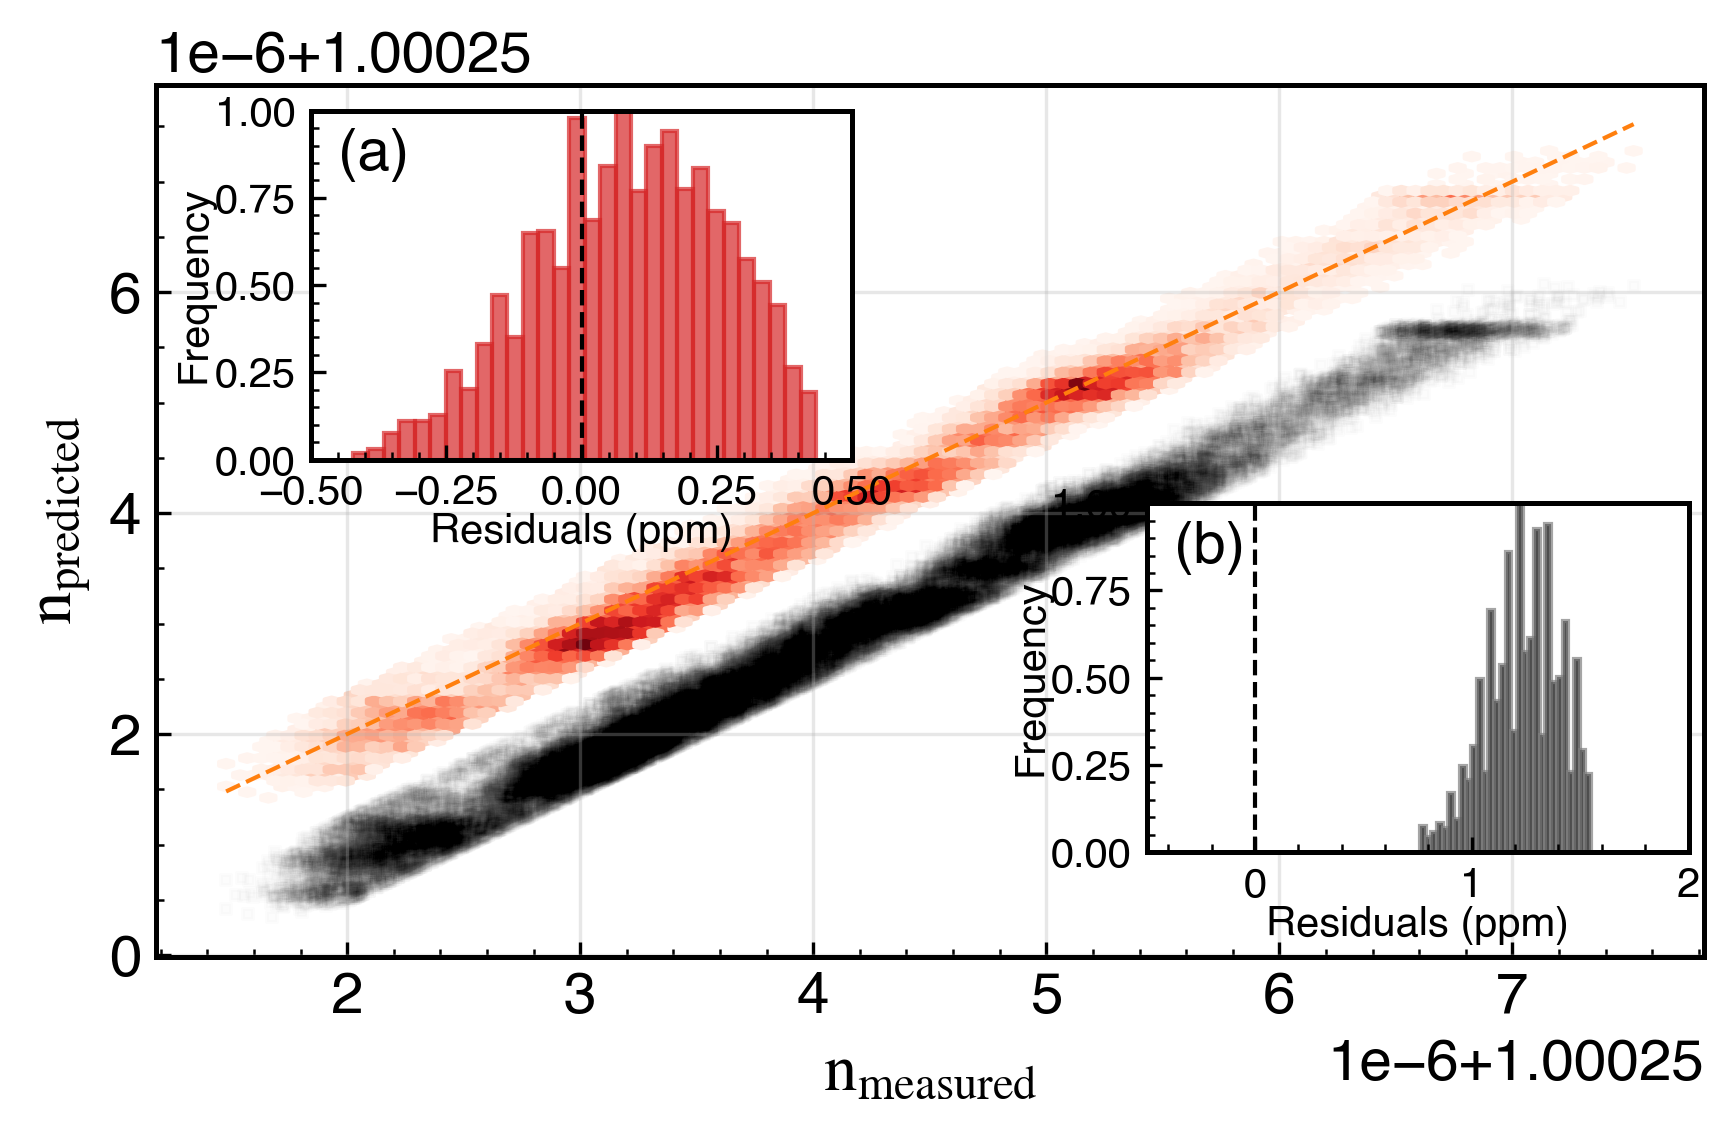

In [6]:
# 1. Load regression results from JSON
results_json = load_regression_results('regression_results.json')

# 2. Create validation plot
validation_results = create_validation_plot(
    validation_data_path='../../data/processed/validation_data.csv',
    results_json=results_json,
    mathar_n_function=n
)